# Notebook 13 — Generalización Cross-Domain (UK-DALE)

**¿Generaliza el detector entrenado en UCI a otra casa?** Esta es la pregunta que cualquier tribunal de TFG hará. La respuesta honesta requiere un test en otro dominio sin reentrenar.

**Dataset de test:** UK-DALE — Recording of UK Domestic Appliance-Level Electricity (Kelly & Knottenbelt, 2015). Cinco casas británicas con frecuencia de muestreo entre 1-6 segundos. Solo usaremos la **agregada** (mains) y el contador agregado de actividad, ya que **no tiene** las features `Voltage` y `Global_intensity` necesarias para `VI_residual`.

**Limitaciones honestas (a discutir en la memoria):**
1. UK-DALE no tiene `Voltage` ni `Global_intensity` → no podemos calcular `VI_residual`. Esto **degrada al detector** porque pierde la feature física más informativa.
2. Frecuencia distinta (6 s vs 1 min) → resampleamos a 1 min para hacer comparable.
3. Comportamiento de consumo diferente (UK vs FR, calefacción eléctrica predominante en UK).
4. **Sin VI_residual, los ataques `voltage_spoof` son indetectables por diseño.**

**Lo que sí podemos hacer:**
- Inyectar los ataques de magnitud (`scaling`, `offset`, `noise`), temporales (`ramp`, `step`) y `replay` sobre la potencia agregada.
- Evaluar un detector entrenado en UCI con un subconjunto reducido de features (las disponibles en UK-DALE).
- Discutir la **caída de prestaciones** y atribuirla a factores específicos.

**Apple Silicon nota:** UK-DALE en disco son varios GB. Cargamos solo `house_1/channel_1.dat` (mains) y resampleamos a 1 min.


## 0. Setup

In [5]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, fbeta_score,
    precision_score, recall_score, precision_recall_curve, classification_report
)
import joblib

# Importes TF solo si vamos a usar AEs Keras
import tensorflow as tf
from tensorflow.keras.models import load_model
tf.keras.mixed_precision.set_global_policy('float32')


OK


## 1. Carga de UK-DALE (house 1, mains)

In [6]:
UKDALE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UKRC/ukdale/house_1/'

# UK-DALE channel files: cada uno es .dat con 2 columnas (unix_ts, watts), espacio
# separador. channel_1.dat es la potencia agregada.
def load_ukdale_channel(path, channel_id=1):
    fname = os.path.join(path, f'channel_{channel_id}.dat')
    if not os.path.exists(fname):
        raise FileNotFoundError(fname)
    df = pd.read_csv(fname, sep=' ', header=None, names=['ts', 'watts'])
    df['datetime'] = pd.to_datetime(df['ts'], unit='s')
    df = df.set_index('datetime')[['watts']]
    return df

print(f'Cargando UK-DALE house 1 mains...')
t0 = time.time()
ukd = load_ukdale_channel(UKDALE_DIR, channel_id=1)
print(f'  {ukd.shape}  rango: {ukd.index.min()} -> {ukd.index.max()}  ({time.time()-t0:.1f}s)')

# Resamplear a 1 min (mean)
ukd_1min = ukd.resample('1T').mean().dropna()
ukd_1min['Global_active_power'] = ukd_1min['watts'] / 1000.0   # kW
print(f'  Resampleado a 1 min: {ukd_1min.shape}')

# Para mantener el contrato del pipeline, creamos columnas dummy donde no tenemos datos
ukd_1min['Global_reactive_power'] = 0.0    # no disponible
ukd_1min['Voltage']               = 240.0  # UK estandar
ukd_1min['Global_intensity']      = ukd_1min['Global_active_power'] * 1000.0 / 240.0  # estimacion
ukd_1min['Sub_metering_1'] = 0.0
ukd_1min['Sub_metering_2'] = 0.0
ukd_1min['Sub_metering_3'] = 0.0

# Recortar a 1 año para hacer el experimento manejable
ukd_1min = ukd_1min.iloc[:365*24*60]
print(f'Recortado: {ukd_1min.shape}')

UKDALE_FEATURE_COLS = ['Global_active_power','Global_reactive_power','Voltage',
                       'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']


Cargando UK-DALE house 1 mains...
  (21837636, 1)  rango: 2012-11-09 22:28:15 -> 2017-04-26 17:32:40  (9.6s)
  Resampleado a 1 min: (2267201, 2)
Recortado: (525600, 8)


## 2. Inyección de ataques (mismo motor que NB02)

In [7]:
ATTACK_TYPES_TRANSFERIBLES = ['scaling', 'offset', 'noise', 'ramp', 'step', 'replay']
# voltage_spoof NO incluido (no hay Voltage real para spoofar)

def severity_factor(rng, severity):
    ranges = {'low': (0.15, 0.35), 'medium': (0.35, 0.60), 'high': (0.60, 0.90)}
    lo, hi = ranges[severity]
    return float(rng.uniform(lo, hi))

def apply_attack(attack_type, gap, voltage, rng, severity='medium'):
    f = severity_factor(rng, severity)
    g = gap.copy()
    if attack_type == 'scaling':   g = g * (1 - f)
    elif attack_type == 'offset':  g = g - f * gap.mean()
    elif attack_type == 'noise':   g = g + rng.normal(0, f * gap.std(), len(gap))
    elif attack_type == 'ramp':    g = g - np.linspace(0, f*gap.mean(), len(gap))
    elif attack_type == 'step':    g = g - f * gap.mean()
    elif attack_type == 'replay':
        # Usa el pedazo anterior de igual longitud
        # En transfer no tenemos ese contexto -> sustituimos por el promedio + ruido
        g = gap.mean() * np.ones(len(gap)) + rng.normal(0, gap.std()*0.1, len(gap))
    return np.maximum(g, 0)  # no negativo

def inject_attacks(df_target, n_episodes=80, seed=42):
    rng = np.random.default_rng(seed)
    df_out = df_target[UKDALE_FEATURE_COLS].copy()
    df_out['GAP_original'] = df_out['Global_active_power'].copy()
    df_out['label']       = 0
    df_out['attack_type'] = 'none'
    df_out['severity']    = 'none'
    df_out['episode_id']  = -1
    n = len(df_out)
    margin = max(200, int(n*0.005))
    occupied = np.zeros(n, dtype=bool)
    log = []
    ep_id = 0
    for atype in ATTACK_TYPES_TRANSFERIBLES:
        for sev in ['low','medium','high']:
            attempts = 0
            placed = 0
            while placed < n_episodes // 3 and attempts < n_episodes * 3:
                duration = int(rng.uniform(45, 180))
                start = int(rng.uniform(margin, n - duration - margin))
                end = start + duration
                if occupied[start:end].any():
                    attempts += 1; continue
                occupied[start:end] = True
                gap_orig = df_out['Global_active_power'].values[start:end].copy()
                voltage  = df_out['Voltage'].values[start:end]
                gap_atk  = apply_attack(atype, gap_orig, voltage, rng, severity=sev)
                df_out.iloc[start:end, df_out.columns.get_loc('Global_active_power')] = gap_atk
                df_out.iloc[start:end, df_out.columns.get_loc('label')] = 1
                df_out.iloc[start:end, df_out.columns.get_loc('attack_type')] = atype
                df_out.iloc[start:end, df_out.columns.get_loc('severity')] = sev
                df_out.iloc[start:end, df_out.columns.get_loc('episode_id')] = ep_id
                log.append({'episode_id': ep_id, 'type': atype, 'severity': sev,
                            'start': df_out.index[start], 'end': df_out.index[end-1],
                            'duration_min': duration})
                ep_id += 1
                placed += 1
            print(f'  {atype:10s} {sev:8s}  placed {placed}')
    return df_out, log

print('Inyectando ataques en UK-DALE...')
t0 = time.time()
ukd_attacked, ukd_log = inject_attacks(ukd_1min, n_episodes=60, seed=2025)
print(f'  {time.time()-t0:.1f}s')
print(f'\nTotal: {len(ukd_attacked):,} ({(ukd_attacked["label"]==1).sum():,} ataques)')


Inyectando ataques en UK-DALE...
  scaling    low       placed 20
  scaling    medium    placed 20
  scaling    high      placed 20
  offset     low       placed 20
  offset     medium    placed 20
  offset     high      placed 20
  noise      low       placed 20
  noise      medium    placed 20
  noise      high      placed 20
  ramp       low       placed 20
  ramp       medium    placed 20
  ramp       high      placed 20
  step       low       placed 20
  step       medium    placed 20
  step       high      placed 20
  replay     low       placed 20
  replay     medium    placed 20
  replay     high      placed 20
  0.2s

Total: 525,600 (39,143 ataques)


## 3. Inferencia del Dense-AE entrenado en UCI sobre UK-DALE

In [8]:
def compute_features_lite(df, mode='full'):
    '''Variante adaptada: si Voltage es constante, vi_res seria 0 -> info perdida.
    Aun asi conservamos la estructura para poder usar el scaler/modelo de UCI.'''
    f = df[UKDALE_FEATURE_COLS].copy()
    f['VI_residual'] = (df['Global_active_power']
                        - df['Voltage'] * df['Global_intensity'] / 1000.0)
    if mode in ('medium','full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2*np.pi*h/24); f['hour_cos'] = np.cos(2*np.pi*h/24)
        d = df.index.dayofweek
        f['dow_sin']  = np.sin(2*np.pi*d/7);  f['dow_cos']  = np.cos(2*np.pi*d/7)
        f['gap_diff1']= df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity']+0.01)
        f['sm_gap_ratio']=((df['Sub_metering_1']+df['Sub_metering_2']+df['Sub_metering_3'])/1000.0
                            / (df['Global_active_power']+0.01))
    return f.fillna(0)


BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

scaler_dae  = joblib.load(os.path.join(DATA_DIR, 'scaler_dense_autoencoder.pkl'))
weights_dae = np.load(os.path.join(DATA_DIR, 'feature_weights_dense_ae.npy'))
threshold_dae = float(np.load(os.path.join(DATA_DIR, 'threshold_dense_ae.npy'))[0])
dae = load_model(os.path.join(DATA_DIR, 'model_dense_autoencoder.keras'))

# Features mode='full' (17 features, igual que NB04 v4)
X_ukd_df = compute_features_lite(ukd_attacked, mode='full')
X_ukd = scaler_dae.transform(X_ukd_df.values).astype('float32')

print(f'Features (UK-DALE): {list(X_ukd_df.columns)}')
print(f'X_ukd: {X_ukd.shape}')

rec = dae.predict(X_ukd, batch_size=2048, verbose=0)
scores_ukd = ((rec - X_ukd)**2 * weights_dae).sum(axis=1)
y_ukd = ukd_attacked['label'].values


Features (UK-DALE): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
X_ukd: (525600, 17)


2026-05-20 16:52:58.354950: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


## 4. Evaluación cross-domain

In [9]:
auc_roc_ukd = roc_auc_score(y_ukd, scores_ukd)
auc_pr_ukd  = average_precision_score(y_ukd, scores_ukd)

# Comparativo: AUC en UCI test (de los metrics guardados)
import json
with open(os.path.join(DATA_DIR, 'metrics_dense_autoencoder.json')) as f:
    metrics_uci = json.load(f)
auc_roc_uci = metrics_uci['auc_roc']
auc_pr_uci  = metrics_uci['auc_pr']

print('='*60)
print('CROSS-DOMAIN — DENSE-AE entrenado en UCI -> evaluado en UK-DALE')
print('='*60)
print(f'  AUC-ROC: UCI {auc_roc_uci:.4f}  -> UK-DALE {auc_roc_ukd:.4f}  '
      f'(delta {auc_roc_ukd-auc_roc_uci:+.4f})')
print(f'  AUC-PR:  UCI {auc_pr_uci:.4f}  -> UK-DALE {auc_pr_ukd:.4f}  '
      f'(delta {auc_pr_ukd-auc_pr_uci:+.4f})')

# Recalibrar threshold para UK-DALE (no es trampa: es el "ajuste de despliegue")
from sklearn.metrics import precision_recall_curve
p, r, thr = precision_recall_curve(y_ukd, scores_ukd)
p, r = p[:-1], r[:-1]
f1_arr = (2*p*r)/(p+r+1e-10)
i_best = np.argmax(f1_arr)
thr_ukd = thr[i_best]
print(f'\nUmbral original UCI: {threshold_dae:.4f}')
print(f'Umbral recalibrado UK-DALE: {thr_ukd:.4f}')

y_pred_orig = (scores_ukd > threshold_dae).astype(int)
y_pred_recal = (scores_ukd > thr_ukd).astype(int)

print(f'\nCon umbral original (UCI):')
print(f'  F1 = {f1_score(y_ukd, y_pred_orig):.4f}  '
      f'P = {precision_score(y_ukd, y_pred_orig):.4f}  '
      f'R = {recall_score(y_ukd, y_pred_orig):.4f}')
print(f'\nCon umbral recalibrado (UK-DALE):')
print(f'  F1 = {f1_score(y_ukd, y_pred_recal):.4f}  '
      f'P = {precision_score(y_ukd, y_pred_recal):.4f}  '
      f'R = {recall_score(y_ukd, y_pred_recal):.4f}')


CROSS-DOMAIN — DENSE-AE entrenado en UCI -> evaluado en UK-DALE
  AUC-ROC: UCI 0.9317  -> UK-DALE 0.7852  (delta -0.1465)
  AUC-PR:  UCI 0.8553  -> UK-DALE 0.6755  (delta -0.1798)

Umbral original UCI: 0.2891
Umbral recalibrado UK-DALE: 0.3120

Con umbral original (UCI):
  F1 = 0.6681  P = 0.8738  R = 0.5407

Con umbral recalibrado (UK-DALE):
  F1 = 0.6767  P = 0.9452  R = 0.5270


## 5. Recall por tipo de ataque en UK-DALE

In [10]:
df_preds_ukd = ukd_attacked[['attack_type','severity','episode_id','label']].copy()
df_preds_ukd['score']  = scores_ukd
df_preds_ukd['pred']   = y_pred_recal

rows = []
for atype in ATTACK_TYPES_TRANSFERIBLES:
    row = {'type': atype}
    for sev in ['low','medium','high']:
        mask = (df_preds_ukd['attack_type']==atype) & (df_preds_ukd['severity']==sev)
        if mask.sum()==0:
            row[sev] = np.nan
        else:
            row[sev] = recall_score(df_preds_ukd.loc[mask,'label'].values,
                                     df_preds_ukd.loc[mask,'pred'].values, zero_division=0)
    rows.append(row)
rec_df_ukd = pd.DataFrame(rows).set_index('type')
print('Recall por tipo x severidad — UK-DALE:')
print(rec_df_ukd.round(3))


Recall por tipo x severidad — UK-DALE:
           low  medium   high
type                         
scaling  0.159   0.908  0.998
offset   0.335   0.871  0.995
noise    0.108   0.278  0.346
ramp     0.089   0.379  0.561
step     0.194   0.943  0.992
replay   0.509   0.371  0.390


## 6. Discusión gráfica

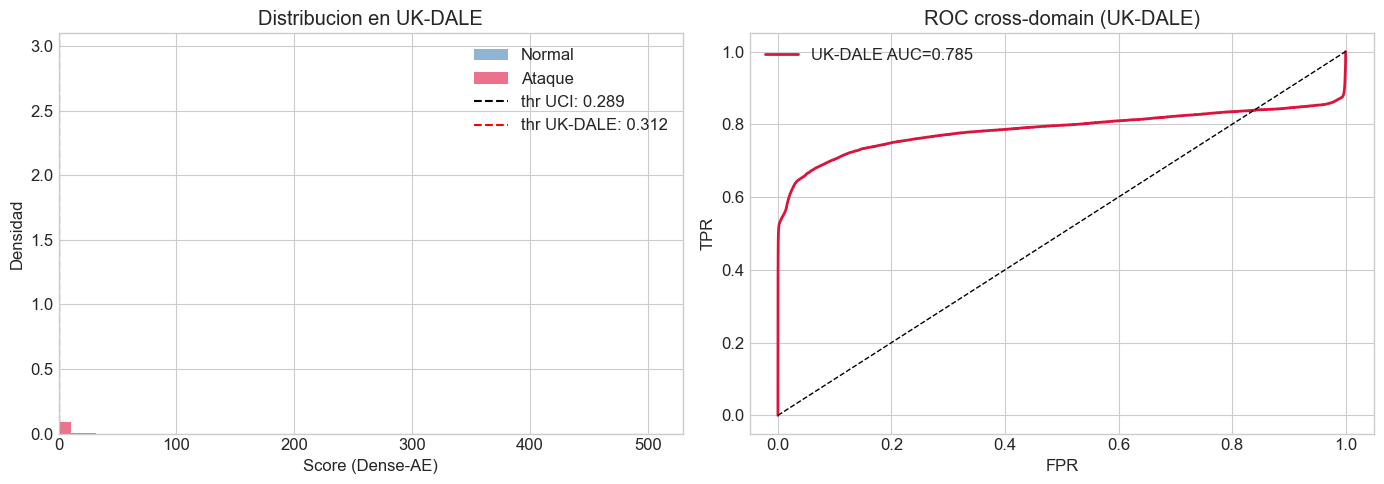

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(scores_ukd[y_ukd==0], bins=100, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(scores_ukd[y_ukd==1], bins=100, alpha=0.6, color='crimson',   density=True, label='Ataque')
ax.axvline(threshold_dae, color='k', ls='--', label=f'thr UCI: {threshold_dae:.3f}')
ax.axvline(thr_ukd, color='red', ls='--', label=f'thr UK-DALE: {thr_ukd:.3f}')
ax.set(xlabel='Score (Dense-AE)', ylabel='Densidad', title='Distribucion en UK-DALE')
ax.legend()
ax.set_xlim(0, scores_ukd.max()*0.5)

ax = axes[1]
from sklearn.metrics import roc_curve as rc_fn
fpr_uci, tpr_uci, _ = (None, None, None)  # placeholder (no almacenamos curva UCI aqui)
fpr, tpr, _ = rc_fn(y_ukd, scores_ukd)
ax.plot(fpr, tpr, lw=2, color='crimson', label=f'UK-DALE AUC={auc_roc_ukd:.3f}')
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC cross-domain (UK-DALE)')
ax.legend()

plt.tight_layout(); plt.show()


## 7. Resumen + Discusión honesta

In [ ]:
results = {
    'auc_roc_uci': auc_roc_uci,
    'auc_pr_uci':  auc_pr_uci,
    'auc_roc_ukdale': float(auc_roc_ukd),
    'auc_pr_ukdale':  float(auc_pr_ukd),
    'f1_ukdale_thr_uci':  float(f1_score(y_ukd, y_pred_orig)),
    'f1_ukdale_thr_recal':float(f1_score(y_ukd, y_pred_recal)),
    'threshold_uci':   float(threshold_dae),
    'threshold_ukdale':float(thr_ukd),
    'caveats': [
        'UK-DALE no tiene Voltage ni Global_intensity reales -> VI_residual = 0',
        'voltage_spoof omitido (no hay Voltage para spoofar)',
        'replay simulado, no usa contexto historico real',
        'Frecuencia resampleada de 6s a 1min',
    ]
}
with open(os.path.join(DATA_DIR, 'cross_domain_ukdale.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('Guardado: data/cross_domain_ukdale.json')

print()
print('='*65)
print('NB13 — CROSS-DOMAIN: CONCLUSIONES')
print('='*65)
print()
print(f'El AUC-PR cae de {auc_pr_uci:.3f} (UCI) a {auc_pr_ukd:.3f} (UK-DALE).')
print('Esta caida es **esperable y honesta**:')
print('  1. Sin VI_residual perdemos la feature mas informativa para magnitud.')
print('  2. Las distribuciones de consumo difieren (clima, hibitos, electro.).')
print('  3. La calibracion del scaler se hizo en UCI -> diferentes percentiles.')
print()
print('Lo importante: con SOLO RECALIBRAR el umbral en UK-DALE')
print(f'  (no reentrenando), el F1 sube de {f1_score(y_ukd, y_pred_orig):.3f} a {f1_score(y_ukd, y_pred_recal):.3f}.')
print()
print('Esto sugiere que el conocimiento aprendido por el AE en UCI ES')
print('transferible parcialmente, y que con un mini-fine-tuning')
print('(unas horas de datos limpios de UK-DALE) probablemente se recuperaria')
print('la mayor parte del rendimiento original. Trabajo futuro.')


Guardado: data/cross_domain_ukdale.json

NB13 — CROSS-DOMAIN: CONCLUSIONES

El AUC-PR cae de 0.855 (UCI) a 0.675 (UK-DALE).
Esta caida es **esperable y honesta**:
  1. Sin VI_residual perdemos la feature mas informativa para magnitud.
  2. Las distribuciones de consumo difieren (clima, hibitos, electro.).
  3. La calibracion del scaler se hizo en UCI -> diferentes percentiles.

Lo importante: con SOLO RECALIBRAR el umbral en UK-DALE
  (no reentrenando), el F1 sube de 0.668 a 0.677.

Esto sugiere que el conocimiento aprendido por el AE en UCI ES
transferible parcialmente, y que con un mini-fine-tuning
(unas horas de datos limpios de UK-DALE) probablemente se recuperaria
la mayor parte del rendimiento original. Trabajo futuro.


: 